In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("../data/sandbox_products.csv")

In [32]:
df.head()

,Product Name,Price,Rating,Availability,Product URL
0,Lightweight Probiotics,$155.62,4.0,In Stock,https://scrapingsandbox.com/product/1
1,Wireless LED Desk Lamp,$145.40,4.6,Out of Stock,https://scrapingsandbox.com/product/2
2,Deluxe Tea Collection,$185.01,3.5,In Stock,https://scrapingsandbox.com/product/3
3,Essential Tire Gauge,$70.86,3.6,Out of Stock,https://scrapingsandbox.com/product/4
4,Smart Carving Tools,$97.13,3.5,In Stock,https://scrapingsandbox.com/product/5


In [33]:
df.shape

(500, 5)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  500 non-null    str    
 1   Price         500 non-null    str    
 2   Rating        500 non-null    float64
 3   Availability  500 non-null    str    
 4   Product URL   500 non-null    str    
dtypes: float64(1), str(4)
memory usage: 19.7 KB


In [35]:
df.isnull().sum()

Product Name    0
Price           0
Rating          0
Availability    0
Product URL     0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df["Price"] = df["Price"].str.replace("$", "", regex=False).astype(float)

In [38]:
df["Price"].head()

0    155.62
1    145.40
2    185.01
3     70.86
4     97.13
Name: Price, dtype: float64

In [39]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [40]:
df["Rating"].head()

0    4.0
1    4.6
2    3.5
3    3.6
4    3.5
Name: Rating, dtype: float64

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  500 non-null    str    
 1   Price         500 non-null    float64
 2   Rating        500 non-null    float64
 3   Availability  500 non-null    str    
 4   Product URL   500 non-null    str    
dtypes: float64(2), str(3)
memory usage: 19.7 KB


In [42]:
print("Total Products:", len(df))

print("Average Price:", df["Price"].mean())

print("Minimum Price:", df["Price"].min())

print("Maximum Price:", df["Price"].max())

Total Products: 500
Average Price: 104.10006000000001
Minimum Price: 5.12
Maximum Price: 204.86


In [43]:
df["Rating"].value_counts()

Rating
4.6    33
4.8    32
3.4    30
4.4    28
4.7    28
3.5    27
4.3    27
3.3    27
3.7    26
4.1    25
3.6    24
4.2    24
4.9    22
3.2    22
3.9    21
3.1    20
3.8    19
4.0    18
4.5    18
3.0    16
5.0    13
Name: count, dtype: int64

In [44]:
df["Rating"].value_counts().sort_index()

Rating
3.0    16
3.1    20
3.2    22
3.3    27
3.4    30
3.5    27
3.6    24
3.7    26
3.8    19
3.9    21
4.0    18
4.1    25
4.2    24
4.3    27
4.4    28
4.5    18
4.6    33
4.7    28
4.8    32
4.9    22
5.0    13
Name: count, dtype: int64

In [45]:
most_common_rating = df["Rating"].mode()[0]

print("Most common rating:", most_common_rating)

Most common rating: 4.6


In [46]:
df["Availability"].value_counts()


Availability
In Stock        427
Out of Stock     73
Name: count, dtype: int64

In [47]:
availability_percent = df["Availability"].value_counts(normalize=True) * 100

print(availability_percent)

Availability
In Stock        85.4
Out of Stock    14.6
Name: proportion, dtype: float64


In [48]:
import matplotlib.pyplot as plt

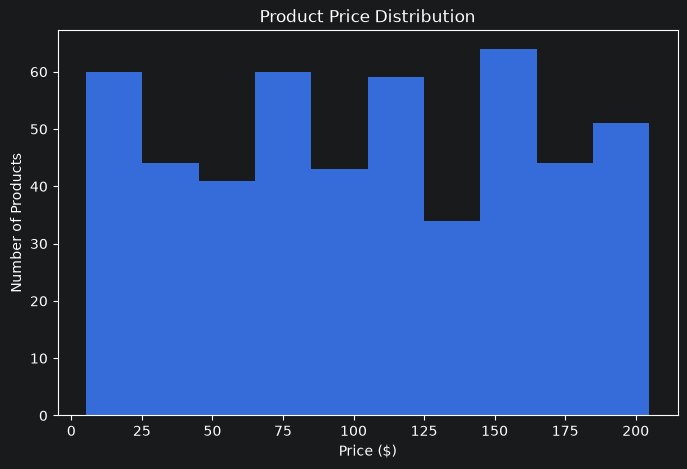

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=10)

plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.show()

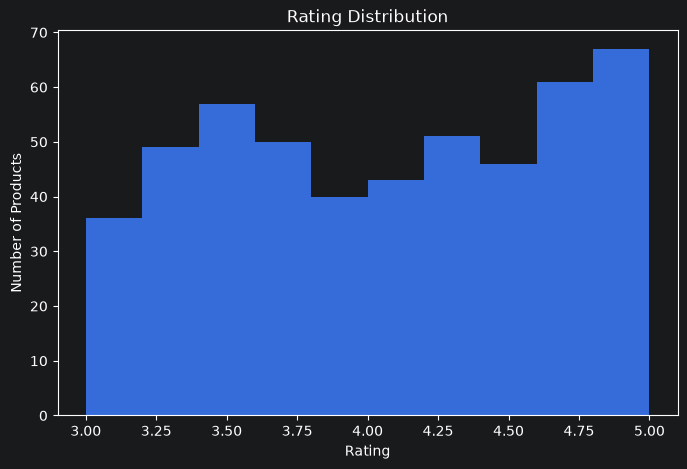

In [50]:
plt.figure(figsize=(8, 5))

plt.hist(df["Rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

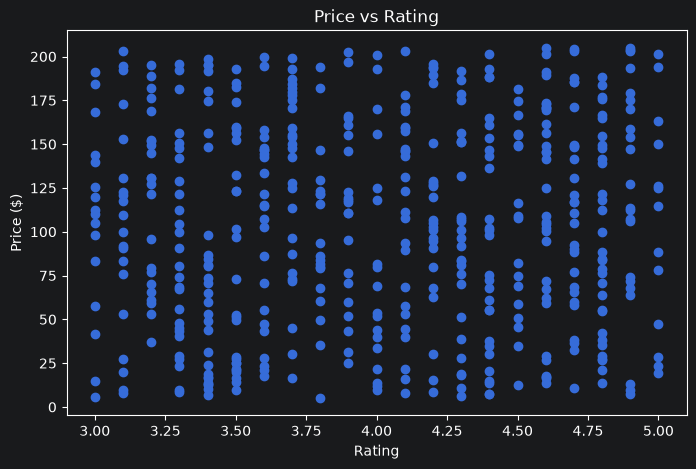

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Rating"], df["Price"])

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price ($)")

plt.show()

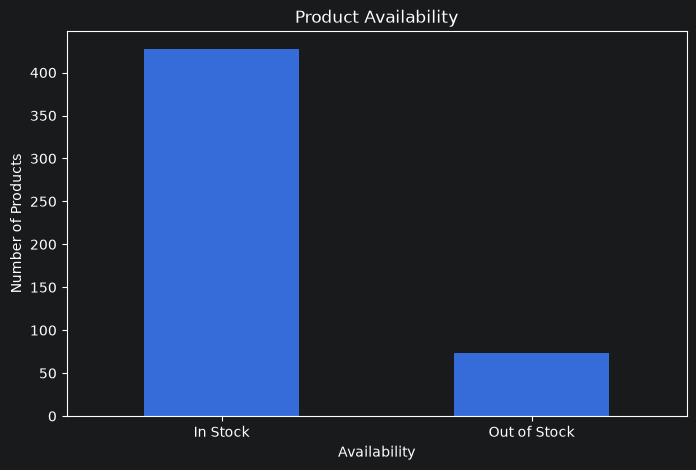

In [52]:
plt.figure(figsize=(8, 5))

df["Availability"].value_counts().plot(kind="bar")

plt.title("Product Availability")
plt.xlabel("Availability")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.show()

In [53]:
highest_rated = df.sort_values(
    by="Rating",
    ascending=False
).head(10)

highest_rated[[
    "Product Name",
    "Rating",
    "Price",
    "Availability"
]]

,Product Name,Rating,Price,Availability
145,Vintage Body Chain,5.0,126.03,In Stock
161,Premium Omega-3 Capsules,5.0,201.63,Out of Stock
14,Vintage Stuffed Animal,5.0,124.84,In Stock
164,Smart Jump Rope,5.0,150.09,In Stock
212,Premium Charger,5.0,23.65,In Stock
228,Vintage Sweatband,5.0,114.50,In Stock
271,Compact Travel Guide,5.0,19.33,In Stock
260,Pro Grooming Brush,5.0,77.92,In Stock
375,Handcrafted Vinyl Record,5.0,163.48,In Stock
119,Smart Cardigan,5.0,28.73,In Stock


In [54]:
lowest_priced = df.sort_values(
    by="Price",
    ascending=True
).head(10)

lowest_priced[[
    "Product Name",
    "Price",
    "Rating",
    "Availability"
]]

,Product Name,Price,Rating,Availability
313,Organic Eye Cream,5.12,3.8,In Stock
214,Portable Hair Pin,5.66,3.0,In Stock
76,Modern Coffee Beans,6.22,4.3,In Stock
176,Premium Spice Set,6.68,3.4,In Stock
178,Professional Sun Shade,7.31,4.4,In Stock
233,Wireless Coloring Book,7.36,4.4,In Stock
102,Smart Storage Basket,7.55,4.9,In Stock
173,Advanced Eye Cream,7.70,4.1,In Stock
376,Heavy-Duty Microphone,7.77,3.1,Out of Stock
315,Deluxe SSD Drive,8.33,4.2,In Stock


In [55]:
print("===== E-COMMERCE DATA ANALYSIS SUMMARY =====")

print("Total Products:", len(df))
print("Average Price: $", round(df["Price"].mean(), 2))
print("Minimum Price: $", round(df["Price"].min(), 2))
print("Maximum Price: $", round(df["Price"].max(), 2))

print("Most Common Rating:", df["Rating"].mode()[0])

print("\nAvailability:")
print(df["Availability"].value_counts())

print("\nHighest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())

===== E-COMMERCE DATA ANALYSIS SUMMARY =====
Total Products: 500
Average Price: $ 104.1
Minimum Price: $ 5.12
Maximum Price: $ 204.86
Most Common Rating: 4.6

Availability:
Availability
In Stock        427
Out of Stock     73
Name: count, dtype: int64

Highest Rating: 5.0
Lowest Rating: 3.0


In [56]:
print("===== FINAL DATA VALIDATION =====")

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

===== FINAL DATA VALIDATION =====
Missing values:
Product Name    0
Price           0
Rating          0
Availability    0
Product URL     0
dtype: int64

Duplicate rows:
0

Data types:
Product Name        str
Price           float64
Rating          float64
Availability        str
Product URL         str
dtype: object


In [57]:
df.to_csv("../data/sandbox_products_cleaned.csv", index=False)

df.to_excel("../data/sandbox_products_cleaned.xlsx", index=False)

print("Cleaned CSV and Excel files saved successfully!")

Cleaned CSV and Excel files saved successfully!
